In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
merged=pd.read_csv("../Processed/merged.csv")

In [12]:
latest_season = merged['season'].max()
last_3_seasons = [latest_season - 2, latest_season - 1, latest_season]

df3 = merged[merged['season'].isin(last_3_seasons)]



In [13]:
retained_players = {
    # CSK
    'RD Gaikwad',
    'M Pathirana',
    'S Dube',
    'RA Jadeja',
    'MS Dhoni',

    # DC
    'AR Patel',
    'Kuldeep Yadav',
    'T Stubbs',
    'Abishek Porel',

    # GT
    'Rashid Khan',
    'Shubman Gill',
    'B Sai Sudharsan',
    'R Tewatia',
    'M Shahrukh Khan',

    # KKR
    'RK Singh',
    'CV Varun',
    'SP Narine',
    'AD Russell',
    'Harshit Rana',
    'Ramandeep Singh',

    # LSG
    'N Pooran',
    'Ravi Bishnoi',
    'Mayank Yadav',
    'Mohsin Khan',
    'A Badoni',

    # MI
    'JJ Bumrah',
    'SA Yadav',
    'HH Pandya',
    'RG Sharma',
    'Tilak Varma',

    # PBKS
    'Shashank Singh',
    'P Simran Singh',

    # RR
    'SV Samson',
    'YBK Jaiswal',
    'R Parag',
    'Dhruv Jurel',
    'SO Hetmyer',
    'Sandeep Sharma',

    # RCB
    'V Kohli',
    'RM Patidar',
    'Yash Dayal',
   
    # SRH
    'PJ Cummins',
    'Abhishek Sharma',
    'Nithish Kumar Reddy',
    'H Klaasen',
    'TM Head'
}


In [14]:
df_bat_auction = df3[~df3['batter'].isin(retained_players)].copy()
df_bowl_auction = df3[~df3['bowler'].isin(retained_players)].copy()
df_field_auction = df3[~df3['fielder'].isin(retained_players)].copy()
dismissals = df3[df3['player_dismissed'].notna()]
dismissals = dismissals[~dismissals['player_dismissed'].isin(retained_players)]


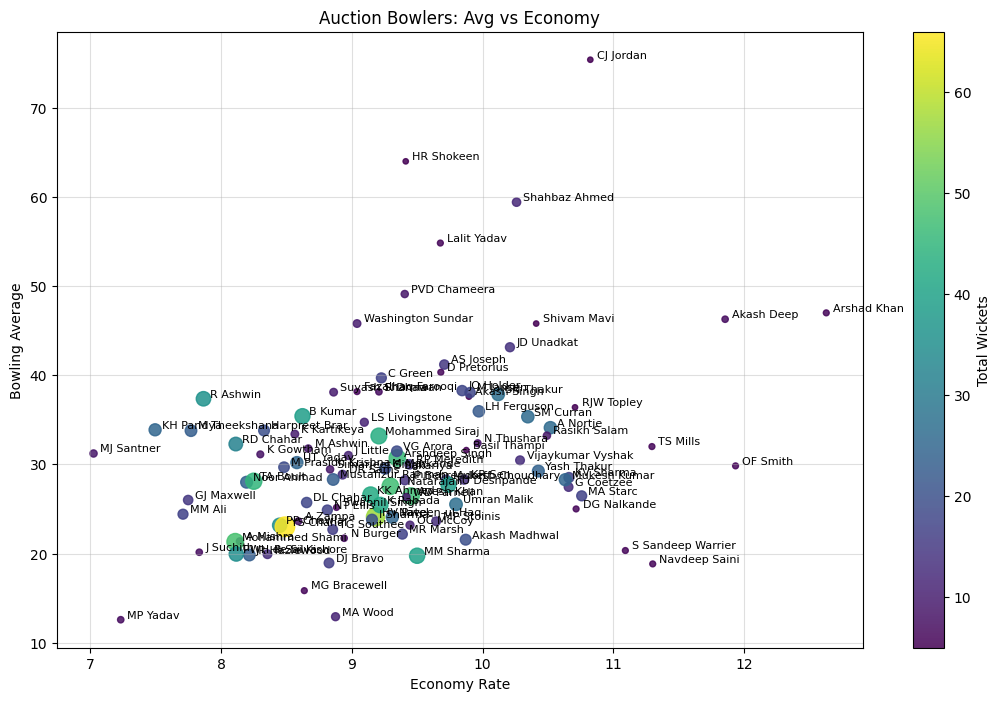

<Figure size 640x480 with 0 Axes>

In [15]:
df_bowl_auction = df3[~df3['bowler'].isin(retained_players)].copy()

bowler_wkts = df_bowl_auction[
    (df_bowl_auction['is_wicket'] == 1) &
    (df_bowl_auction['dismissal_kind'] != 'run out')
].groupby('bowler').size()

runs_conceded = df_bowl_auction.groupby('bowler')['total_runs'].sum()

legal_balls = df_bowl_auction[~df_bowl_auction['extras_type'].isin(['wides', 'noballs'])]
balls = legal_balls.groupby('bowler').size()

bowl = pd.concat([bowler_wkts, runs_conceded, balls], axis=1)
bowl.columns = ['wickets', 'runs', 'balls']
bowl = bowl.dropna()

bowl['overs'] = bowl['balls'] / 6
bowl['avg'] = bowl['runs'] / bowl['wickets']
bowl['econ'] = bowl['runs'] / bowl['overs']

bowl = bowl[(bowl['balls'] >= 50) & (bowl['wickets'] >= 5)]

plt.figure(figsize=(13,8))

sc = plt.scatter(
    bowl['econ'],
    bowl['avg'],
    c=bowl['wickets'],
    s=bowl['wickets'] * 3,
    alpha=0.85
)

for player in bowl.index:
    plt.text(
        bowl.loc[player,'econ'] + 0.05,
        bowl.loc[player,'avg'] + 0.2,
        player,
        fontsize=8
    )

plt.colorbar(sc, label='Total Wickets')
plt.xlabel('Economy Rate')
plt.ylabel('Bowling Average')
plt.title('Auction Bowlers: Avg vs Economy')
plt.grid(alpha=0.4)
plt.show()
plt.savefig('../Images/Bowling_Selection(Avg vs Econ).png', dpi=150, bbox_inches='tight')


In [16]:
df_bowl_auction = df3[~df3['bowler'].isin(retained_players)].copy()

df_bowl_auction['is_legal_ball'] = ~df_bowl_auction['extras_type'].isin(['wides', 'noballs'])
df_bowl_auction['phase'] = pd.cut(
    df_bowl_auction['over'],
    bins=[-1, 5, 14, 19],
    labels=['Powerplay', 'Middle', 'Death']
)

legal = df_bowl_auction[df_bowl_auction['is_legal_ball']]

wkts = df_bowl_auction[
    (df_bowl_auction['is_wicket'] == 1) &
    (df_bowl_auction['dismissal_kind'] != 'run out')
]

wkt_phase = wkts.groupby(['phase', 'bowler']).size().rename('wickets')

runs_phase = df_bowl_auction.groupby(['phase', 'bowler'])['total_runs'].sum().rename('runs')

balls_phase = legal.groupby(['phase', 'bowler']).size().rename('balls')

dots_phase = legal.groupby(['phase', 'bowler'])['total_runs'].apply(lambda x: (x == 0).sum()).rename('dot_balls')

phase_stats = pd.concat([wkt_phase, runs_phase, balls_phase, dots_phase], axis=1).fillna(0).reset_index()

phase_stats = phase_stats[phase_stats['balls'] >= 10]

best_bowlers = (
    phase_stats
    .sort_values(['phase', 'wickets', 'dot_balls'], ascending=[True, False, False])
    .groupby('phase')
    .head(15)
)

for phase, data in best_bowlers.groupby('phase'):
    print(f"\n=== {phase} : Auction Targets ===")
    print(
        data[['bowler','wickets','dot_balls','runs','balls']]
        .sort_values(['wickets','dot_balls'], ascending=False)
        .reset_index(drop=True)
    )



=== Powerplay : Auction Targets ===
            bowler  wickets  dot_balls  runs  balls
0         TA Boult     32.0        341   757    642
1   Mohammed Shami     28.0        285   602    504
2          B Kumar     20.0        282   744    576
3   Mohammed Siraj     20.0        258   785    534
4         K Rabada     18.0        162   519    354
5   Arshdeep Singh     16.0        175   620    402
6        DL Chahar     15.0        116   376    266
7         KK Ahmed     14.0        198   528    402
8         UT Yadav     13.0        186   487    372
9     TU Deshpande     13.0        166   516    366
10        M Jansen     13.0        128   382    264
11        I Sharma     13.0        101   305    210
12        VG Arora     12.0        113   403    277
13      Avesh Khan     12.0        111   424    264
14     T Natarajan     12.0         99   347    234

=== Middle : Auction Targets ===
           bowler  wickets  dot_balls  runs  balls
0       YS Chahal     35.0        225  1057   

Powerplay Bowlers

Trent Boult — elite swing, early wickets

Mohammed Shami — seam control, strike threat

Bhuvneshwar Kumar — movement + economy stability

Mohammed Siraj — aggressive lengths

Arshdeep Singh — left arm variation

Deepak Chahar — swing specialist

Khaleel Ahmed — angle + new ball wickets

Marco Jansen — bounce advantage

Ishant Sharma — control spells (seen on chart cluster)

Washington Sundar — powerplay spin choke (chart avg/econ)


Middle Order Bowlers

Yuzvendra Chahal — wicket machine

Ravichandran Ashwin — tactical control

Sunil Narine — elite economy cluster

Mujeeb Ur Rahman — mystery spin pressure

Krunal Pandya — control overs

Mayank Markande — attacking leg spin

Noor Ahmad — variation threat

Harpreet Brar — defensive role

Glenn Maxwell — matchup off spin (chart presence)

Moeen Ali — flexible contro

Mitchell Santner - Left arm off-spin (slow deliveries)


Death Bowlers

Harshal Patel — slower ball specialist

T Natarajan — yorker accuracy

Avesh Khan — pace + wickets

Mustafizur Rahman — cutter specialist

Bhuvneshwar Kumar — death variations

Mohammed Siraj — aggressive option

Shardul Thakur — breakthrough overs

Mukesh Kumar — control role

Sandeep Sharma — variation specialist 

Chris Jordan — death experience 